# Введение в машинное обучение

## Глава IV: Теорема Байеса и наивный байесовский классификатор

Это решение содержит примеры выполнения всех заданий из главы IV.

### Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
from scipy.optimize import minimize_scalar

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

## Задание 1: Условная вероятность

### 1.1. Формула условной вероятности

Формула условной вероятности:

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

### 1.2. Задача с шарами

In [2]:
# В коробке 5 красных и 3 синих шара
# Вероятность того, что второй шар красный при условии, что первый был синим
# После извлечения синего шара осталось: 5 красных и 2 синих
red_balls = 5
blue_balls = 2
total_balls = red_balls + blue_balls

prob_second_red_given_first_blue = red_balls / total_balls
print(f"Вероятность того, что второй шар красный при условии, что первый был синим: {prob_second_red_given_first_blue:.4f}")

Вероятность того, что второй шар красный при условии, что первый был синим: 0.7143


### 1.3. Независимость событий

In [3]:
# Монета подбрасывается дважды
# Событие A: первый бросок дал орла
# Событие B: второй бросок дал орла

# Вероятность орла при одном броске
p_head = 0.5

# P(A) = P(первый бросок = орел) = 0.5
p_a = p_head

# P(B) = P(второй бросок = орел) = 0.5
p_b = p_head

# P(A и B) = P(оба броска = орел) = 0.5 * 0.5 = 0.25
p_a_and_b = p_head * p_head

# P(A|B) = P(A и B) / P(B) = 0.25 / 0.5 = 0.5
p_a_given_b = p_a_and_b / p_b

print(f"P(A) = {p_a}")
print(f"P(B) = {p_b}")
print(f"P(A и B) = {p_a_and_b}")
print(f"P(A|B) = {p_a_given_b}")
print(f"\nПроверка независимости: P(A|B) = P(A)? {p_a_given_b == p_a}")
print(f"События A и B независимы, так как P(A|B) = P(A)")

P(A) = 0.5
P(B) = 0.5
P(A и B) = 0.25
P(A|B) = 0.5

Проверка независимости: P(A|B) = P(A)? True
События A и B независимы, так как P(A|B) = P(A)


## Задание 2: Тест на коронавирус

### 2.1. Формула теоремы Байеса

Формула теоремы Байеса:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

где:
- $P(A|B)$ — апостериорная вероятность (вероятность A при условии B)
- $P(B|A)$ — правдоподобие (вероятность B при условии A)
- $P(A)$ — априорная вероятность (вероятность A до наблюдения B)
- $P(B)$ — нормализующая константа (вероятность B)

### 2.2. Решение задачи

In [4]:
# Данные задачи
total_population = 8_000_000_000
p_disease = 0.01  # 1% населения заболело
p_no_disease = 1 - p_disease

# Ошибки теста
false_positive_rate = 0.04  # Ошибка первого рода: 4%
false_negative_rate = 0.01  # Ошибка второго рода: 1%

# Вероятности теста
p_positive_given_disease = 1 - false_negative_rate  # 99%
p_positive_given_no_disease = false_positive_rate  # 4%

# P(положительный тест) = P(положительный|болен) * P(болен) + P(положительный|не болен) * P(не болен)
p_positive = (p_positive_given_disease * p_disease + 
              p_positive_given_no_disease * p_no_disease)

# Теорема Байеса: P(болен|положительный тест)
p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print(f"Вероятность того, что человек болен при положительном тесте: {p_disease_given_positive:.4f} ({p_disease_given_positive*100:.2f}%)")
print(f"\nЭто означает, что даже при положительном тесте вероятность болезни составляет всего {p_disease_given_positive*100:.2f}%")

Вероятность того, что человек болен при положительном тесте: 0.2000 (20.00%)

Это означает, что даже при положительном тесте вероятность болезни составляет всего 20.00%


## Задание 3: Улучшаем тест

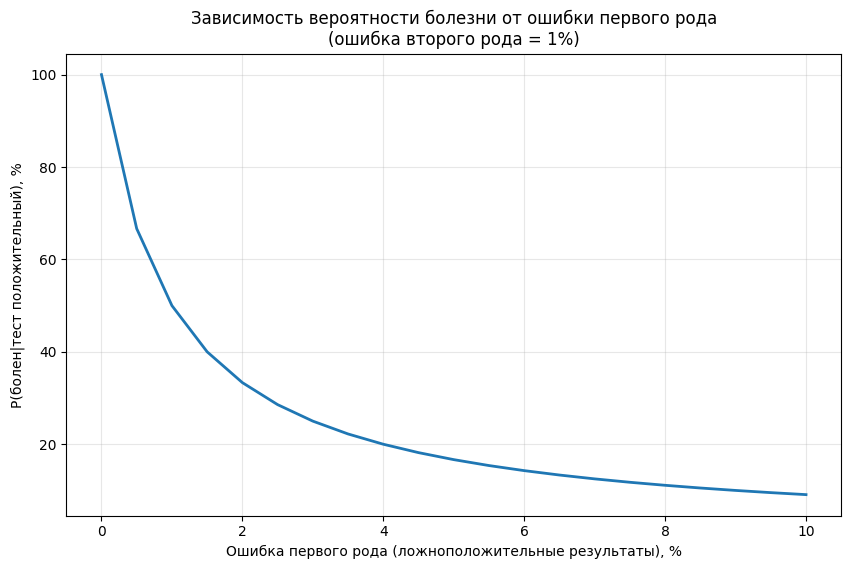

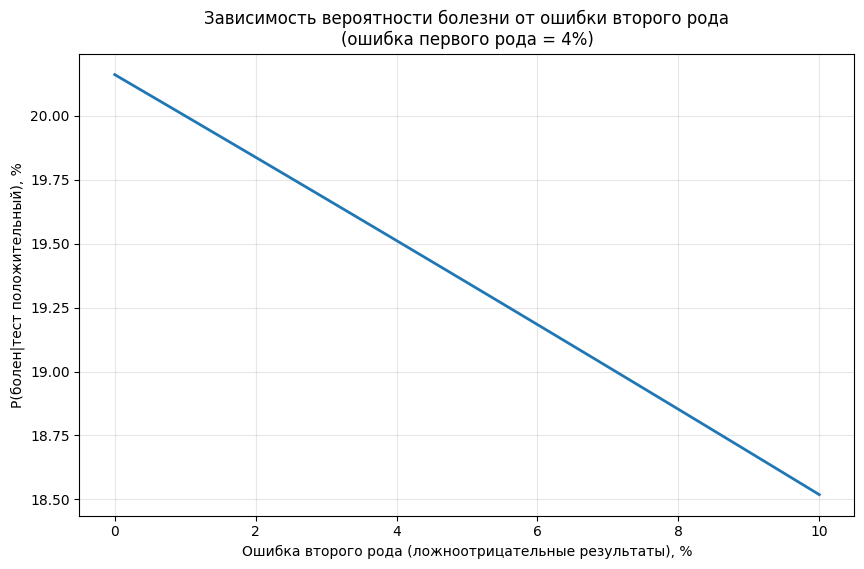


Вывод: Уменьшение ошибки первого рода (ложноположительных результатов) 
более эффективно повышает P(болен|тест положительный), так как 
при низкой распространенности болезни ложноположительные результаты 
сильно снижают точность диагностики.


In [5]:
# Функция для вычисления P(болен|тест положительный)
def prob_disease_given_positive(false_positive, false_negative, p_disease=0.01):
    p_no_disease = 1 - p_disease
    p_positive_given_disease = 1 - false_negative
    p_positive_given_no_disease = false_positive
    
    p_positive = (p_positive_given_disease * p_disease + 
                  p_positive_given_no_disease * p_no_disease)
    
    return (p_positive_given_disease * p_disease) / p_positive

# График 1: зависимость от ошибки первого рода
false_positive_range = np.arange(0, 0.101, 0.005)  # от 0% до 10% с шагом 0.5%
false_negative_fixed = 0.01  # фиксированная ошибка второго рода

prob_values_1 = [prob_disease_given_positive(fp, false_negative_fixed) 
                 for fp in false_positive_range]

plt.figure(figsize=(10, 6))
plt.plot(false_positive_range * 100, [p * 100 for p in prob_values_1], linewidth=2)
plt.xlabel('Ошибка первого рода (ложноположительные результаты), %')
plt.ylabel('P(болен|тест положительный), %')
plt.title('Зависимость вероятности болезни от ошибки первого рода\n(ошибка второго рода = 1%)')
plt.grid(True, alpha=0.3)
plt.show()

# График 2: зависимость от ошибки второго рода
false_negative_range = np.arange(0, 0.101, 0.005)  # от 0% до 10% с шагом 0.5%
false_positive_fixed = 0.04  # фиксированная ошибка первого рода

prob_values_2 = [prob_disease_given_positive(false_positive_fixed, fn) 
                 for fn in false_negative_range]

plt.figure(figsize=(10, 6))
plt.plot(false_negative_range * 100, [p * 100 for p in prob_values_2], linewidth=2)
plt.xlabel('Ошибка второго рода (ложноотрицательные результаты), %')
plt.ylabel('P(болен|тест положительный), %')
plt.title('Зависимость вероятности болезни от ошибки второго рода\n(ошибка первого рода = 4%)')
plt.grid(True, alpha=0.3)
plt.show()

print("\nВывод: Уменьшение ошибки первого рода (ложноположительных результатов) \n"
      "более эффективно повышает P(болен|тест положительный), так как \n"
      "при низкой распространенности болезни ложноположительные результаты \n"
      "сильно снижают точность диагностики.")

## Задание 4: Загрузка данных

In [6]:
data = pd.read_csv("../production/AI_Machine_Learning.Project_1.ID_1577771/datasets/emails.csv")

print(f"Размерность DataFrame: {data.shape}")
print(f"Столбцы: {list(data.columns)}")

# Проверки
assert not data.empty, "DataFrame не должен быть пустым"
assert "text" in data.columns, "Столбец text должен присутствовать"
assert "spam" in data.columns, "Столбец spam должен присутствовать"
assert set(data["spam"].unique()).issubset({0, 1}), "В столбце spam должны быть только значения 0 и 1"

print("\nВсе проверки пройдены успешно!")

Размерность DataFrame: (5728, 2)
Столбцы: ['text', 'spam']

Все проверки пройдены успешно!


## Задание 5: Изучение данных

### 5.1. Круговая диаграмма

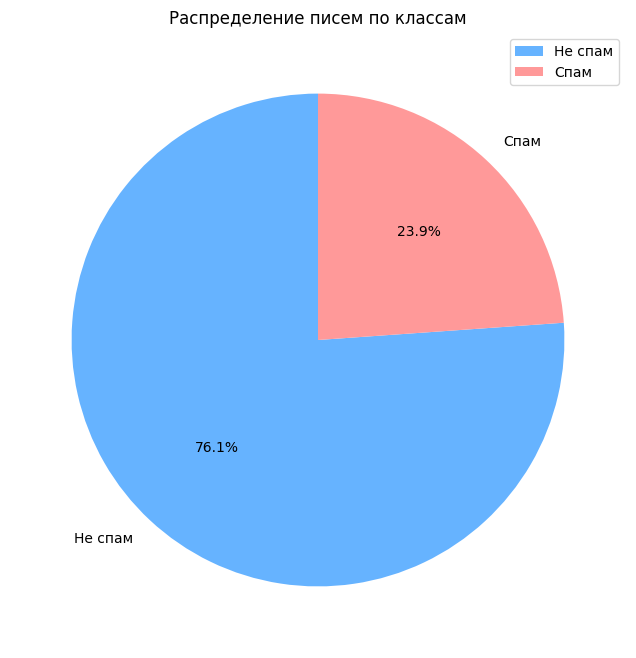

In [7]:
spam_counts = data["spam"].value_counts()
labels = ["Не спам", "Спам"]
colors = ["#66b3ff", "#ff9999"]

plt.figure(figsize=(8, 8))
plt.pie(spam_counts, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
plt.title("Распределение писем по классам")
plt.legend(labels)
plt.show()

### 5.2. Предобработка текста

In [8]:
# Удаляем префикс "Subject: "
data["text_cleaned"] = data["text"].str.replace("Subject: ", "", regex=False)

# Примеры до и после обработки
print("Примеры текстов:")
for i in range(3):
    print(f"\n{i+1}. До обработки:")
    print(data["text"].iloc[i][:100] + "...")
    print(f"После обработки:")
    print(data["text_cleaned"].iloc[i][:100] + "...")

Примеры текстов:

1. До обработки:
Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : ...
После обработки:
naturally irresistible your corporate identity  lt is really hard to recollect a company : the  mark...

2. До обработки:
Subject: the stock trading gunslinger  fanny is merrill but muzo not colza attainder and penultimate...
После обработки:
the stock trading gunslinger  fanny is merrill but muzo not colza attainder and penultimate like esm...

3. До обработки:
Subject: unbelievable new homes made easy  im wanting to show you this  homeowner  you have been pre...
После обработки:
unbelievable new homes made easy  im wanting to show you this  homeowner  you have been pre - approv...


### 5.3. Топ-50 слов

In [9]:
def get_top_words(texts, n=50):
    all_words = []
    for text in texts:
        words = re.findall(r"\b\w+\b", text.lower())
        all_words.extend(words)
    return Counter(all_words).most_common(n)

# Топ-50 для спама
spam_texts = data[data["spam"] == 1]["text_cleaned"]
top_spam = get_top_words(spam_texts, 50)

# Топ-50 для не спама
ham_texts = data[data["spam"] == 0]["text_cleaned"]
top_ham = get_top_words(ham_texts, 50)

print("Топ-50 слов в спам-сообщениях:")
for word, count in top_spam[:10]:
    print(f"{word}: {count}")

print("\nТоп-50 слов в не спам-сообщениях:")
for word, count in top_ham[:10]:
    print(f"{word}: {count}")

Топ-50 слов в спам-сообщениях:
_: 13556
the: 8975
to: 8165
and: 6517
of: 5629
you: 4920
a: 4700
in: 3886
your: 3730
for: 3186

Топ-50 слов в не спам-сообщениях:
the: 41135
to: 33571
and: 20961
of: 18128
i: 15649
a: 15250
you: 14234
in: 14096
for: 13510
enron: 13382


### 5.4. Топ-50 слов без стоп-слов

In [10]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_top_words_no_stop(texts, n=50):
    all_words = []
    for text in texts:
        words = re.findall(r"\b\w+\b", text.lower())
        words = [w for w in words if w not in ENGLISH_STOP_WORDS]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

# Топ-50 для спама без стоп-слов
top_spam_no_stop = get_top_words_no_stop(spam_texts, 50)

# Топ-50 для не спама без стоп-слов
top_ham_no_stop = get_top_words_no_stop(ham_texts, 50)

print("Топ-50 слов в спам-сообщениях (без стоп-слов):")
for word, count in top_spam_no_stop[:10]:
    print(f"{word}: {count}")

print("\nТоп-50 слов в не спам-сообщениях (без стоп-слов):")
for word, count in top_ham_no_stop[:10]:
    print(f"{word}: {count}")

print("\nВывод: После удаления стоп-слов более четко видны различия между спамом и не спамом.")

Топ-50 слов в спам-сообщениях (без стоп-слов):
_: 13556
s: 1342
com: 999
1: 952
business: 844
company: 805
email: 804
information: 740
e: 701
5: 687

Топ-50 слов в не спам-сообщениях (без стоп-слов):
enron: 13382
ect: 11417
vince: 8531
hou: 5569
s: 5173
2000: 4935
kaminski: 4770
com: 4444
subject: 4245
cc: 3889

Вывод: После удаления стоп-слов более четко видны различия между спамом и не спамом.


## Задание 6: Разделение на выборки

Разделение данных на обучающую и тестовую выборки необходимо для оценки способности модели обобщаться на новых данных. Если обучать и тестировать модель на одних и тех же данных, модель может "запомнить" данные вместо того, чтобы выучить общие закономерности (переобучение).

In [11]:
X = data["text_cleaned"]
y = data["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y
)

print(f"Размерность X_train: {X_train.shape}")
print(f"Размерность X_test: {X_test.shape}")
print(f"Размерность y_train: {y_train.shape}")
print(f"Размерность y_test: {y_test.shape}")

Размерность X_train: (4582,)
Размерность X_test: (1146,)
Размерность y_train: (4582,)
Размерность y_test: (1146,)


## Задание 7: Преобразование данных

Текстовые данные нужно преобразовать в числовые векторы, так как алгоритмы машинного обучения работают с числами. Основные методы: Bag of Words (CountVectorizer), TF-IDF (TfidfVectorizer), Word Embeddings.

In [12]:
vectorizer = CountVectorizer(stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Размерность X_train_vec: {X_train_vec.shape}")
print(f"Размерность X_test_vec: {X_test_vec.shape}")

Размерность X_train_vec: (4582, 33081)
Размерность X_test_vec: (1146, 33081)


## Задание 8: Обучение модели

In [13]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f"Точность модели: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print(f"\nМатрица ошибок:")
print(cm)
print("\nИнтерпретация:")
print(f"Истинно отрицательные (TN): {cm[0, 0]} - правильно определены как не спам")
print(f"Ложноположительные (FP): {cm[0, 1]} - не спам определен как спам")
print(f"Ложноотрицательные (FN): {cm[1, 0]} - спам определен как не спам")
print(f"Истинно положительные (TP): {cm[1, 1]} - правильно определены как спам")

Точность модели: 0.9921 (99.21%)

Матрица ошибок:
[[867   5]
 [  4 270]]

Интерпретация:
Истинно отрицательные (TN): 867 - правильно определены как не спам
Ложноположительные (FP): 5 - не спам определен как спам
Ложноотрицательные (FN): 4 - спам определен как не спам
Истинно положительные (TP): 270 - правильно определены как спам


## Задание 9: Отравление модели

In [19]:
# Выбираем несколько спам-сообщений
spam_indices = X_test[y_test == 1].index[:5]
spam_samples = X_test.loc[spam_indices]

# Находим слова, которые часто встречаются в не спаме
ham_words = [word for word, _ in top_ham_no_stop[:20]]

poisoned_vec = vectorizer.transform(spam_samples)
poisoned_proba = model.predict_proba(poisoned_vec)

print("Вероятности того, что модифицированные сообщения являются спамом:")
for i, prob in enumerate(poisoned_proba):
    print(f"Сообщение {i+1}: P(спам) = {prob[1]:.4f}")
    
# Модифицируем сообщения
poisoned_texts = []
for text in spam_samples:
    # Добавляем слова из не спама по 10 раз каждое
    additional_words = []
    for word in ham_words[:5]:
        additional_words.extend([word] * 5)
    additional_text = " ".join(additional_words)
    poisoned_text = text + " " + additional_text
    poisoned_texts.append(poisoned_text)

# Преобразуем и предсказываем
poisoned_vec = vectorizer.transform(poisoned_texts)
poisoned_proba = model.predict_proba(poisoned_vec)

print("Вероятности того, что модифицированные сообщения являются спамом:")
for i, prob in enumerate(poisoned_proba):
    print(f"Сообщение {i+1}: P(спам) = {prob[1]:.4f}")

print("\nВывод: Добавление слов из не спама снижает вероятность классификации как спам.")

Вероятности того, что модифицированные сообщения являются спамом:
Сообщение 1: P(спам) = 1.0000
Сообщение 2: P(спам) = 1.0000
Сообщение 3: P(спам) = 1.0000
Сообщение 4: P(спам) = 1.0000
Сообщение 5: P(спам) = 1.0000
Вероятности того, что модифицированные сообщения являются спамом:
Сообщение 1: P(спам) = 0.0000
Сообщение 2: P(спам) = 0.0000
Сообщение 3: P(спам) = 0.0000
Сообщение 4: P(спам) = 0.0000
Сообщение 5: P(спам) = 0.0000

Вывод: Добавление слов из не спама снижает вероятность классификации как спам.


## Задание 10: TF-IDF вместо CountVectorizer

In [15]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english")

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print(f"Точность модели с TF-IDF: {accuracy_tfidf:.4f} ({accuracy_tfidf*100:.2f}%)")
print(f"Точность модели с CountVectorizer: {accuracy:.4f} ({accuracy*100:.2f}%)")

if accuracy_tfidf > accuracy:
    print("\nTF-IDF показал лучший результат.")
else:
    print("\nCountVectorizer показал лучший результат.")

Точность модели с TF-IDF: 0.9049 (90.49%)
Точность модели с CountVectorizer: 0.9921 (99.21%)

CountVectorizer показал лучший результат.
